# Phase 1 — Exploratory Data Analysis

**Dataset:** Kaggle/ULB Credit Card Fraud Detection (284,807 transactions, 492 fraudulent, 30 features: V1-V28 PCA components + Time + Amount).

This notebook feeds directly into Chapter 4.1 (Dataset Description) of the dissertation. Plotting/summary logic lives in `src/eda.py` so it is unit-tested and reusable rather than duplicated as notebook-only code.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src import eda, data_acquisition, config

data_path = data_acquisition.download_dataset()
df = eda.load_data(data_path)
df.shape

(284807, 31)

## 1. Shape, structure and missing values

Confirm the dataset matches the ToR's stated dimensions (284,807 rows x 31 columns) and that there are no missing values before any further processing.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [3]:
df.isnull().sum().sum()

np.int64(0)

## 2. Amount and Time — the only human-interpretable features

V1-V28 are PCA-transformed and cannot be meaningfully described individually (their original meaning was stripped during anonymisation). Amount and Time are the two features worth describing directly.

In [4]:
df[["Amount", "Time"]].describe()

,Amount,Time
count,284807.000000,284807.000000
mean,88.349619,94813.859575
std,250.120109,47488.145955
min,0.000000,0.000000
25%,5.600000,54201.500000
50%,22.000000,84692.000000
75%,77.165000,139320.500000
max,25691.160000,172792.000000


## 3. Class distribution

Confirm the 0.172% fraud rate stated in the ToR.

In [5]:
summary = eda.summarize_dataset(df)
summary

{'shape': (284807, 31),
 'missing_values_total': 0,
 'class_counts': {0: 284315, 1: 492},
 'fraud_rate_pct': np.float64(0.173),
 'amount_describe': {'count': 284807.0,
  'mean': 88.34961925093134,
  'std': 250.12010924018855,
  'min': 0.0,
  '25%': 5.6,
  '50%': 22.0,
  '75%': 77.16499999999999,
  'max': 25691.16},
 'time_describe': {'count': 284807.0,
  'mean': 94813.85957508067,
  'std': 47488.14595456617,
  'min': 0.0,
  '25%': 54201.5,
  '50%': 84692.0,
  '75%': 139320.5,
  'max': 172792.0}}

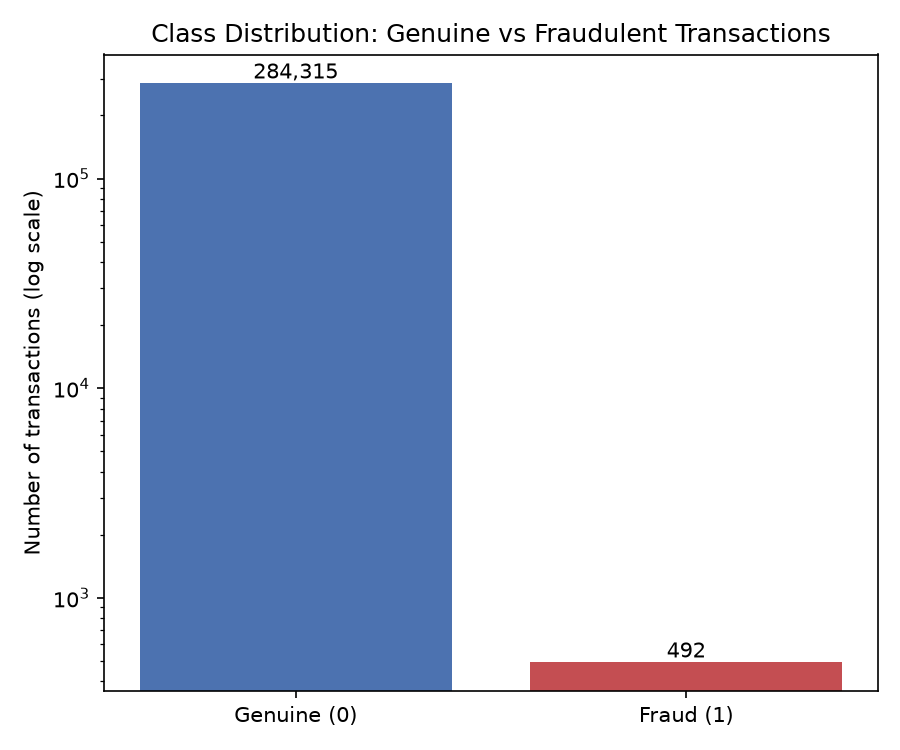

In [6]:
from IPython.display import Image

path = eda.plot_class_distribution(df)
Image(filename=str(path))

**Observation:** fraud is such a small fraction of the data that a linear y-axis would render the fraud bar invisible — hence the log scale. This single plot is the visual justification for everything in Phase 2 (why stratified splitting and imbalance handling are non-negotiable).

## 4. Amount and Time distributions by class

Looking for whether fraud clusters at particular amounts or times of day.

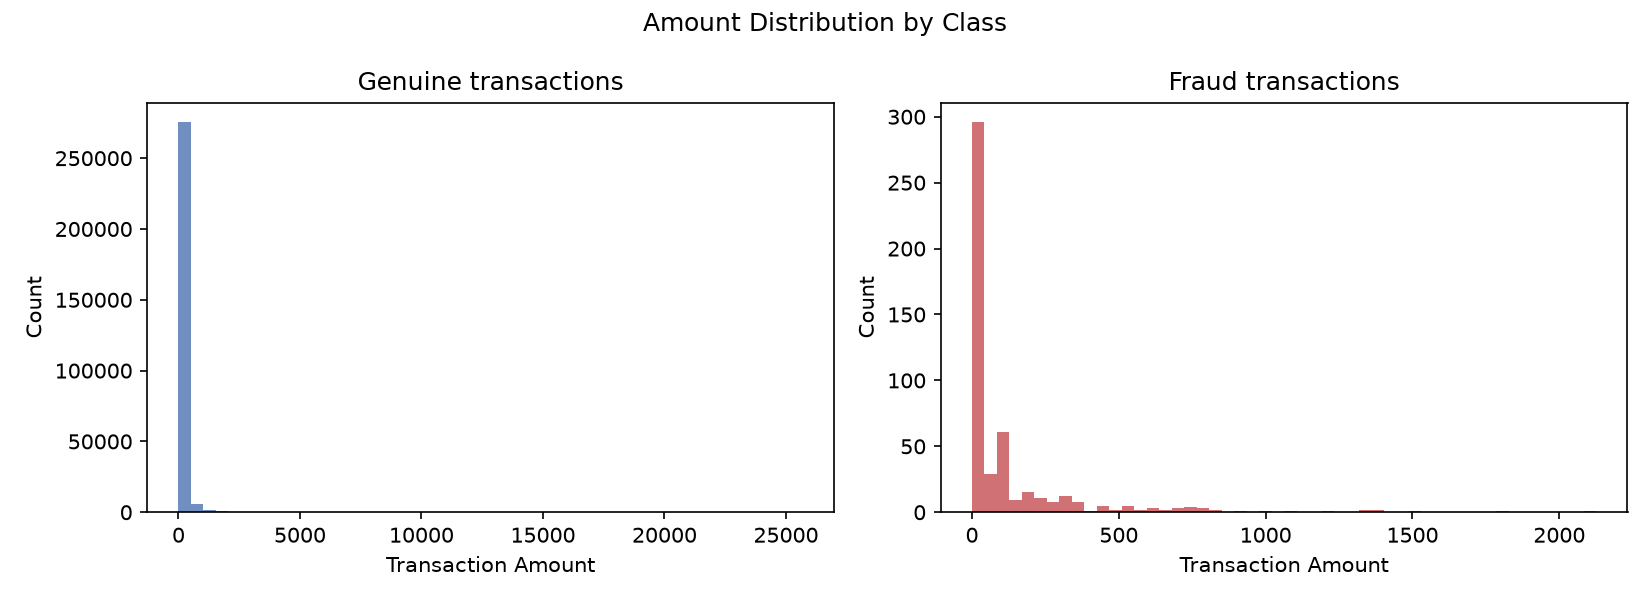

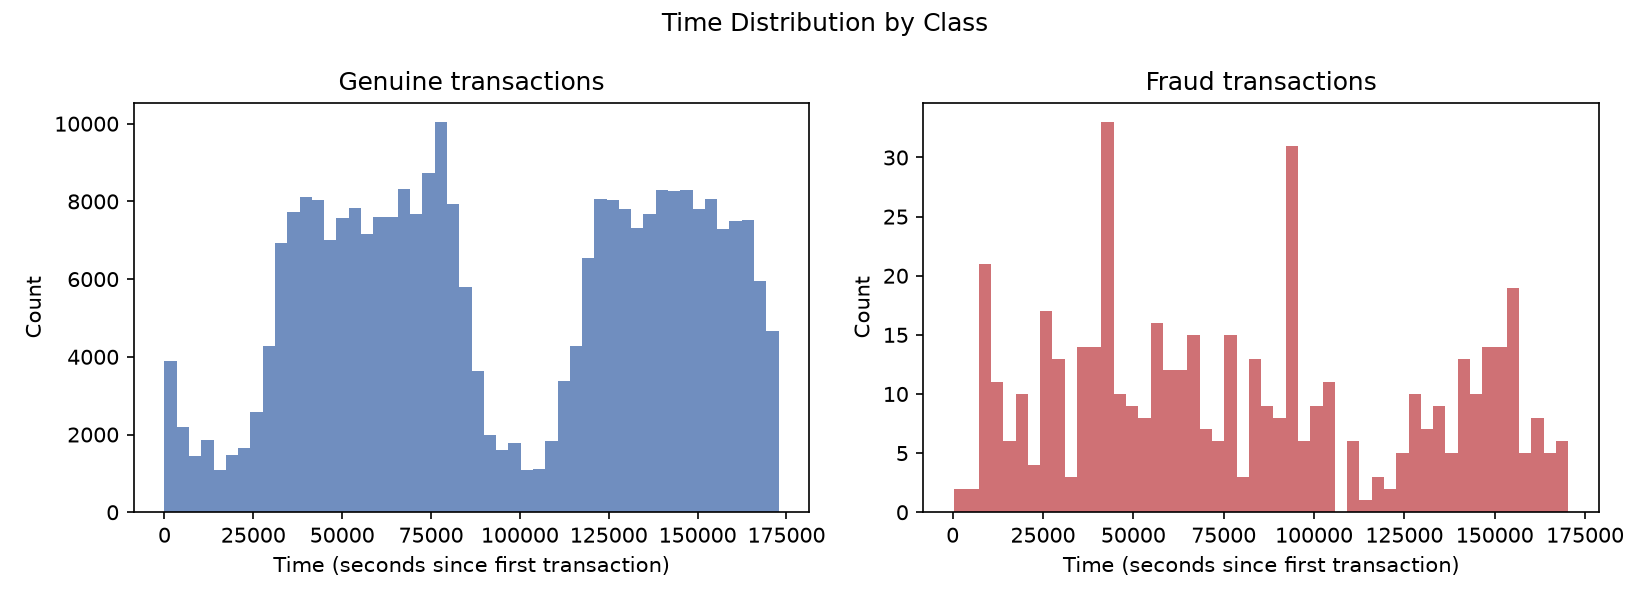

In [7]:
paths = eda.plot_amount_time_by_class(df)
for p in paths:
    display(Image(filename=str(p)))

**Observation:** record here, after viewing the plots, whether fraud amounts skew lower/higher than genuine transactions and whether any time-of-day clustering is visible. (Fill in with the specific pattern seen once this notebook is executed against the real download — this is exactly the kind of observation the dissertation's EDA narrative should state precisely rather than generically.)

## 5. Correlation heatmap

Sanity check: PCA components (V1-V28) should show near-zero correlation with each other by construction.

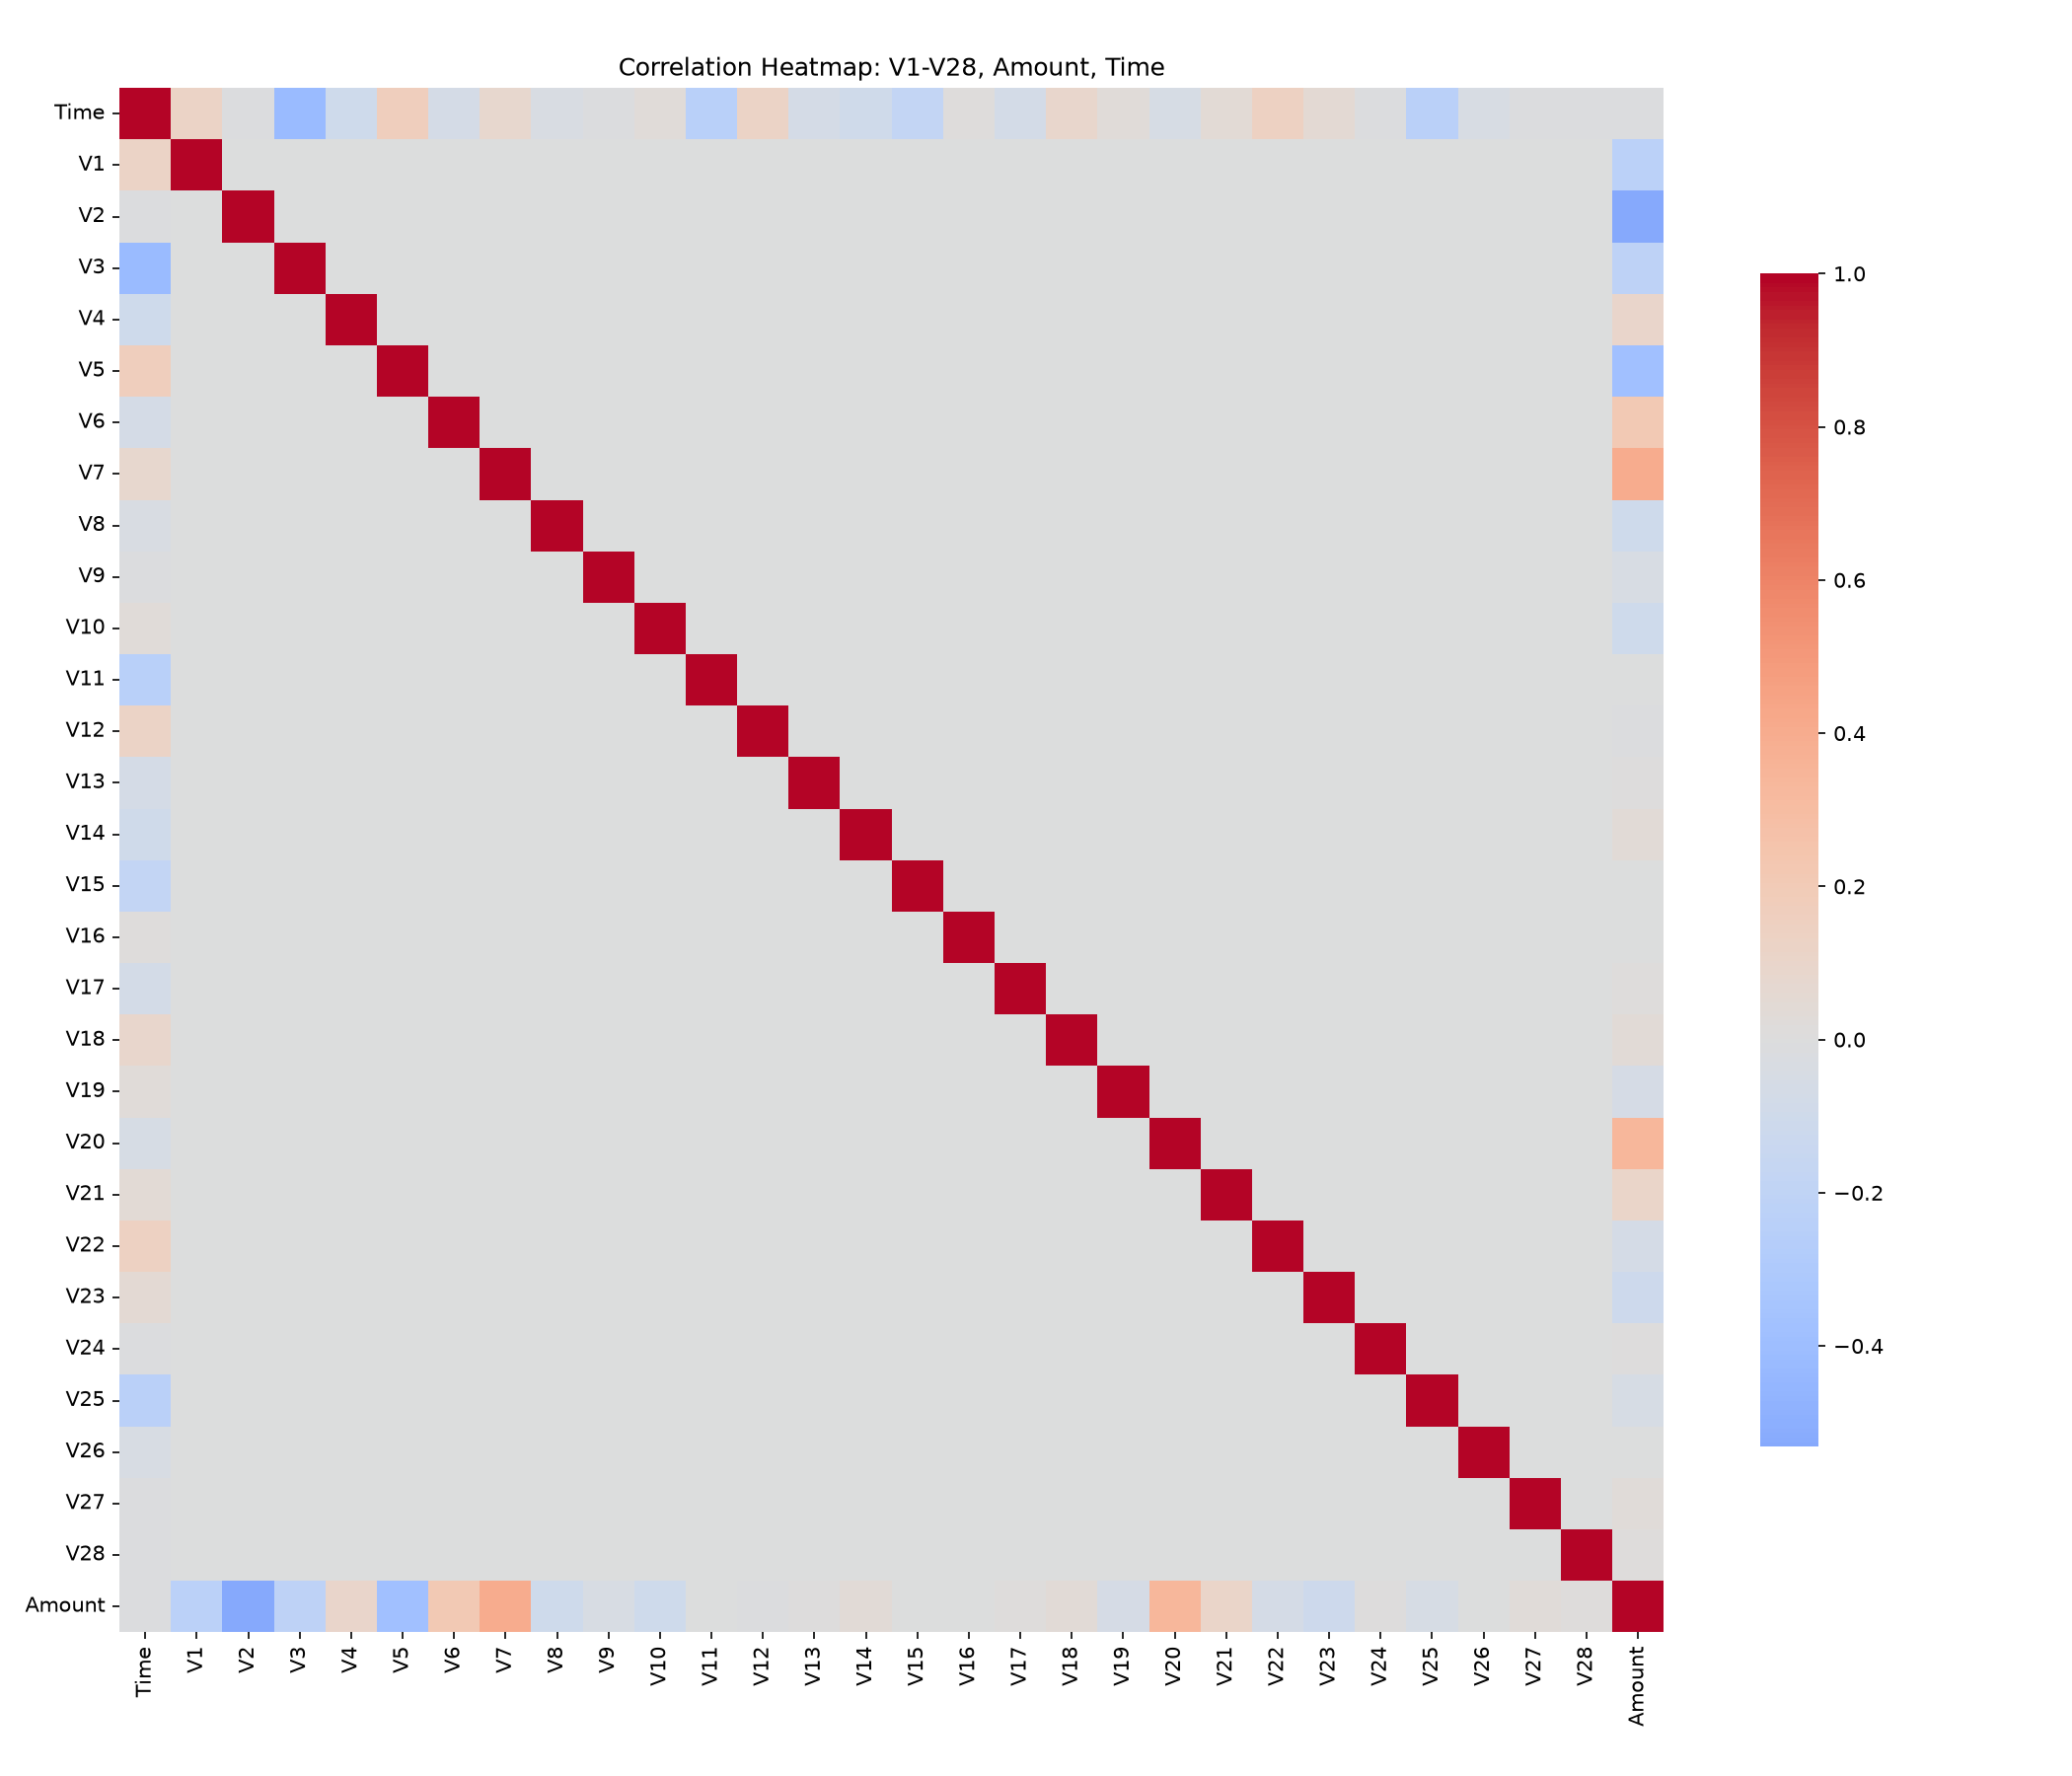

In [8]:
path = eda.plot_correlation_heatmap(df)
Image(filename=str(path))

## Summary of EDA findings

- Dataset shape and missing-value check confirmed against the ToR.
- Severe class imbalance (~0.17% fraud) visually confirmed — motivates Phase 2's imbalance-handling comparison.
- Amount/Time patterns by class noted above for the Chapter 4.1 narrative.
- Correlation heatmap confirms V1-V28 are (as expected) mutually near-uncorrelated, validating the PCA construction claim in the dataset documentation.